In [1]:
import numpy as np

from easydynamics.sample_model import BrownianTranslationalDiffusion

import matplotlib.pyplot as plt

%matplotlib widget

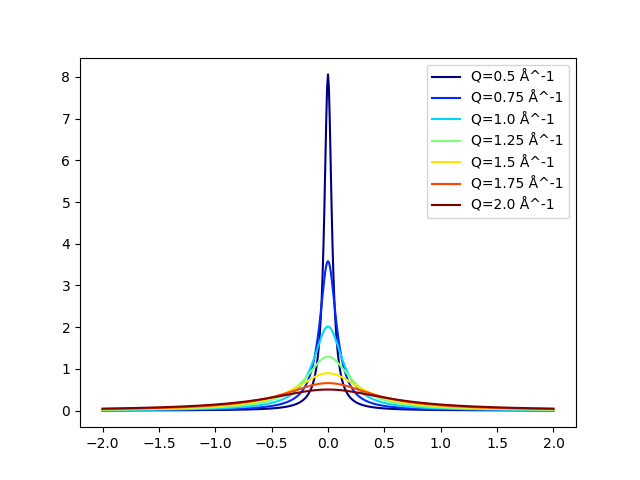

Text(0.5, 1.0, 'Brownian Translational Diffusion Model')

In [2]:
# Create Brownian Translational Diffusion model and plot the model for different Q values.
# Q is in Angstrom^-1 and energy in meV.

Q=np.linspace(0.5,2,7)
energy=np.linspace(-2, 2, 501)
scale=1.0
diffusion_coefficient = 2.4e-9  # m^2/s
diffusion_unit= "m**2/s"

diffusion_model=BrownianTranslationalDiffusion(display_name="DiffusionModel", scale=scale, diffusion_coefficient= diffusion_coefficient, diffusion_unit=diffusion_unit)

component_collections=diffusion_model.create_component_collections(Q)


cmap = plt.cm.jet
nQ = len(component_collections)
plt.figure()
for Q_index in range(len(component_collections)):
    color = cmap(Q_index / (nQ - 1))
    y=component_collections[Q_index].evaluate(energy)
    plt.plot(energy, y, label=f'Q={Q[Q_index]} Å^-1',color=color)
    
plt.legend()
plt.show()
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. units)')
plt.title('Brownian Translational Diffusion Model')    

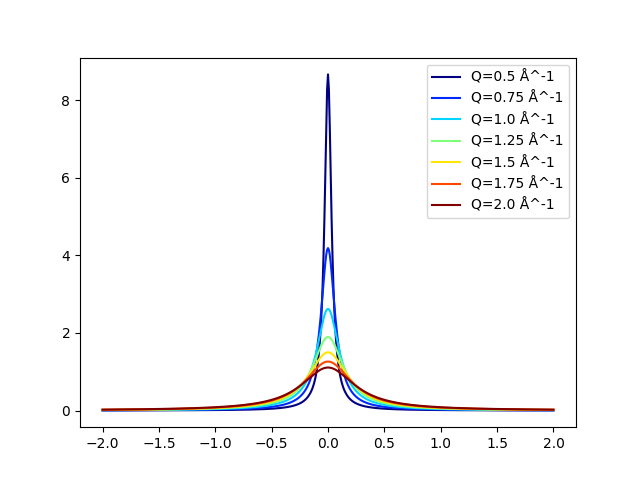

Text(0.5, 1.0, 'Jump Translational Diffusion Model')

In [3]:
from easydynamics.sample_model.diffusion_model.jump_translational_diffusion import JumpTranslationalDiffusion



Q=np.linspace(0.5,2,7)
energy=np.linspace(-2, 2, 501)
scale=1.0
diffusion_coefficient = 2.4e-9  # m^2/s
diffusion_unit= "m**2/s"
relaxation_time=1.25 # ps

diffusion_model=JumpTranslationalDiffusion(display_name="DiffusionModel", scale=scale, diffusion_coefficient= diffusion_coefficient, diffusion_unit=diffusion_unit, relaxation_time=relaxation_time)

component_collections=diffusion_model.create_component_collections(Q)


cmap = plt.cm.jet
nQ = len(component_collections)
plt.figure()
for Q_index in range(len(component_collections)):
    color = cmap(Q_index / (nQ - 1))
    y=component_collections[Q_index].evaluate(energy)
    plt.plot(energy, y, label=f'Q={Q[Q_index]} Å^-1',color=color)
    
plt.legend()
plt.show()
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. units)')
plt.title('Jump Translational Diffusion Model')    

In [4]:
diffusion_model.unit

'meV'

In [19]:
from scipp.constants import hbar as scipp_hbar
import scipp as sc

diffusion_model = JumpTranslationalDiffusion(
    diffusion_coefficient=2.0, relaxation_time=1, diffusion_unit="meV*Å**2"
)

relaxation_time_sc = diffusion_model.relaxation_time.value * sc.Unit(
    diffusion_model.relaxation_time.unit
)
diffusion_coefficient_sc = (
    diffusion_model.diffusion_coefficient.value
    * sc.Unit(diffusion_model.diffusion_coefficient.unit)
)
scipp_hbar

Q_values = sc.linspace("Q", 0.5, 1.5, num=6, unit="1/angstrom")

denominator = (
    diffusion_coefficient_sc * relaxation_time_sc * Q_values**2/ scipp_hbar
)
denominator.unit

# denominator.to(unit="1")
denominator.to(unit="1")

<scipp.Variable> (Q: 6)    float64  [dimensionless]  [0.759634, 1.48888, ..., 5.13512, 6.8367]